In [ ]:
import os, random, gc
import numpy as np
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from einops import rearrange


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)


In [ ]:

from google.colab import drive
drive.mount('/content/drive')

TRAIN_IMG_DIR = "/content/drive/MyDrive/Dataset/GIDsplit/train/image_RGB"
TRAIN_MASK_DIR = "/content/drive/MyDrive/Dataset/GIDsplit/train/label"
VAL_IMG_DIR   = "/content/drive/MyDrive/Dataset/GIDsplit/val/image_RGB"
VAL_MASK_DIR  = "/content/drive/MyDrive/Dataset/GIDsplit/val/label"


CLASS_COLORS = [
    (0,   0,   0),   # 0 background
    (255, 0,   0),   # 1 build-up
    (255, 255, 0),   # 2 farmland
    (0,   255, 0),   # 3 forest
    (0,   255, 255), # 4 meadow
    (0,   0,   255), # 5 water
]
CLASS_NAMES = ["background","build-up","farmland","forest","meadow","water"]
NUM_CLASSES = len(CLASS_COLORS)


NORM_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
NORM_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

IMG_EXTS  = {".png",".jpg",".jpeg",".bmp",".tif",".tiff"}
MASK_EXTS = [".png",".tif",".tiff",".jpg",".jpeg",".bmp"]


Mounted at /content/drive


In [ ]:
from pathlib import Path
import numpy as np
from PIL import Image


def list_images(folder: str|Path):
    p = Path(folder)
    return [x for x in sorted(p.iterdir()) if x.suffix.lower() in IMG_EXTS]

def rgb_to_class(mask_rgb: np.ndarray) -> np.ndarray:
    out = np.zeros(mask_rgb.shape[:2], dtype=np.int64)
    for k,(r,g,b) in enumerate(CLASS_COLORS):
        m = (mask_rgb[...,0]==r) & (mask_rgb[...,1]==g) & (mask_rgb[...,2]==b)
        out[m] = k
    return out

def mask_to_class_any(mask_pil: Image.Image) -> np.ndarray:
    if mask_pil.mode in ("I;16","I","L"):
        return np.array(mask_pil, dtype=np.int64)
    else:
        return rgb_to_class(np.array(mask_pil.convert("RGB"), dtype=np.uint8))


In [ ]:
class GIDPatchDataset(Dataset):

    def __init__(self, image_dir, mask_dir, patch_size=256, samples_per_image=4,
                 mode="train", augment=True, mask_suffix="_label",
                 norm_mean=NORM_MEAN, norm_std=NORM_STD):
        self.image_dir = Path(image_dir)
        self.mask_dir  = Path(mask_dir)
        self.patch_size = patch_size
        self.samples_per_image = samples_per_image
        self.mode = mode
        self.augment = augment and (mode=="train")
        self.mask_suffix = mask_suffix
        self.norm_mean = norm_mean.reshape(1,1,3)
        self.norm_std  = norm_std.reshape(1,1,3)

        self.img_paths = list_images(self.image_dir)
        assert self.img_paths, f"No images found in {image_dir}"
        self.mask_paths = [self._find_mask_path(p) for p in self.img_paths]

        self._sizes = []
        for p in self.img_paths:
            with Image.open(p) as im:
                self._sizes.append(im.size)  

        self.virtual_len = max(1, len(self.img_paths) * (samples_per_image if mode=="train" else 1))

    def _find_mask_path(self, img_path: Path) -> Path:
        stem = img_path.stem
        for ext in MASK_EXTS + [img_path.suffix.lower()]:
            p = self.mask_dir / f"{stem}{self.mask_suffix}{ext}"
            if p.exists(): return p
        for p in self.mask_dir.glob(f"{stem}*label*"):
            if p.suffix.lower() in MASK_EXTS: return p
        raise FileNotFoundError(f"No mask for {img_path.name}")

    def __len__(self): return self.virtual_len

    def _sample_coords(self, W, H):
        ps = self.patch_size
        if self.mode == "train":
            x = 0 if W<=ps else np.random.randint(0, W-ps+1)
            y = 0 if H<=ps else np.random.randint(0, H-ps+1)
        else:
            x = max(0, (W-ps)//2); y = max(0, (H-ps)//2)
        return x, y

    def __getitem__(self, idx):
        idx_img = idx % len(self.img_paths) if self.mode=="train" else idx
        ip, mp = self.img_paths[idx_img], self.mask_paths[idx_img]

        with Image.open(ip) as im: W,H = im.size
        x,y = self._sample_coords(W,H); ps = self.patch_size

        with Image.open(ip) as im:
            crop = im.convert("RGB").crop((x,y,x+ps,y+ps))
            arr  = np.array(crop, np.uint8).astype(np.float32) / 255.0
            arr  = (arr - self.norm_mean) / self.norm_std          # (H,W,3) normalized
            img  = torch.from_numpy(arr).permute(2,0,1).contiguous()

        with Image.open(mp) as ma:
            cropm = ma.crop((x,y,x+ps,y+ps))
            mask  = torch.from_numpy(mask_to_class_any(cropm)).long()

        if self.augment:
            if random.random()<0.5: img,mask = torch.flip(img,[2]), torch.flip(mask,[1])
            if random.random()<0.5: img,mask = torch.flip(img,[1]), torch.flip(mask,[0])
            k = random.randint(0,3)
            if k: img,mask = torch.rot90(img,k,[1,2]), torch.rot90(mask,k,[0,1])

        return img, mask


In [ ]:

class WindowAttention(nn.Module):
    def __init__(self, dim, heads=4, window_size=8, dropout=0.0):
        super().__init__()
        self.ws = window_size
        self.norm = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, heads, dropout=dropout, batch_first=True)

    def forward(self, x):
        B,C,H,W = x.shape
        Ws = self.ws
        pad_h = (Ws - H % Ws) % Ws
        pad_w = (Ws - W % Ws) % Ws
        if pad_h or pad_w:
            x = F.pad(x, (0,pad_w,0,pad_h), mode="replicate")
        Hp,Wp = x.shape[-2:]

        xw = rearrange(x, "b c (nh ws1) (nw ws2) -> (b nh nw) (ws1 ws2) c",
                       ws1=Ws, ws2=Ws)
        xw = self.norm(xw)
        xw,_ = self.attn(xw,xw,xw)

        x = rearrange(xw, "(b nh nw) (ws1 ws2) c -> b c (nh ws1) (nw ws2)",
                      b=B, nh=Hp//Ws, nw=Wp//Ws, ws1=Ws, ws2=Ws)
        if pad_h or pad_w:
            x = x[:,:,:H,:W]
        return x

class TransformerBlock(nn.Module):
    def __init__(self, dim, heads=4, window_size=8, mlp_ratio=4.0, dropout=0.0):
        super().__init__()
        self.attn = WindowAttention(dim, heads=heads, window_size=window_size, dropout=dropout)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, int(dim*mlp_ratio)),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(int(dim*mlp_ratio), dim),
            nn.Dropout(dropout),
        )
    def forward(self,x):
        x = x + self.attn(x)
        B,C,H,W = x.shape
        t = rearrange(x, "b c h w -> b (h w) c")
        t = t + self.mlp(self.norm2(t))
        return rearrange(t,"b (h w) c -> b c h w",h=H,w=W)

class EncoderBlock(nn.Module):
    def __init__(self,in_ch,out_ch,heads=4,window_size=8):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch,out_ch,3,padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
        self.trans = TransformerBlock(out_ch,heads=heads,window_size=window_size)
        self.pool = nn.MaxPool2d(2)
    def forward(self,x):
        x = self.conv(x)
        x = self.trans(x)
        skip = x
        x = self.pool(x)
        return x,skip

class DecoderBlock(nn.Module):
    def __init__(self,in_ch,skip_ch,out_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch,out_ch,2,2)
        self.conv = nn.Sequential(
            nn.Conv2d(out_ch+skip_ch,out_ch,3,padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self,x,skip):
        x = self.up(x)
        x = torch.cat([x,skip],dim=1)
        return self.conv(x)


In [ ]:
class HybridUNetTransformer(nn.Module):
    def __init__(self,in_channels=3,num_classes=6,base_ch=32,
                 window_size=8,heads=(2,4,4,8,8)):
        super().__init__()
        h1,h2,h3,h4,h5 = heads
        self.enc1 = EncoderBlock(in_channels, base_ch,   heads=h1, window_size=window_size)
        self.enc2 = EncoderBlock(base_ch,     base_ch*2, heads=h2, window_size=window_size)
        self.enc3 = EncoderBlock(base_ch*2,   base_ch*4, heads=h3, window_size=window_size)
        self.enc4 = EncoderBlock(base_ch*4,   base_ch*8, heads=h4, window_size=window_size)
        self.enc5 = EncoderBlock(base_ch*8,   base_ch*16,heads=h5, window_size=window_size)

        self.bottleneck = TransformerBlock(base_ch*16, heads=h5, window_size=window_size)

        self.dec5 = DecoderBlock(base_ch*16, base_ch*16, base_ch*8)
        self.dec4 = DecoderBlock(base_ch*8,  base_ch*8,  base_ch*4)
        self.dec3 = DecoderBlock(base_ch*4,  base_ch*4,  base_ch*2)
        self.dec2 = DecoderBlock(base_ch*2,  base_ch*2,  base_ch)
        self.outc = nn.Conv2d(base_ch,num_classes,1)

    def forward(self,x):
        x1,s1 = self.enc1(x)
        x2,s2 = self.enc2(x1)
        x3,s3 = self.enc3(x2)
        x4,s4 = self.enc4(x3)
        x5,s5 = self.enc5(x4)

        b = self.bottleneck(x5)

        d5 = self.dec5(b,s5)
        d4 = self.dec4(d5,s4)
        d3 = self.dec3(d4,s3)
        d2 = self.dec2(d3,s2)
        out = self.outc(d2)
        return F.interpolate(out, size=x.shape[-2:], mode="bilinear", align_corners=False)


In [ ]:
class DecoderBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up   = nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2)
        self.conv = nn.Sequential(
            nn.Conv2d(out_ch + skip_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x, skip):
        x = self.up(x) 
        
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
        x = torch.cat([x, skip], dim=1)
        x = self.conv(x)
        return x


class HybridUNetTransformer(nn.Module):
    
    def __init__(self, in_channels=3, num_classes=6, base_ch=32,
                 window_size=8, heads=(2,4,4,8,8)):
        super().__init__()
        ws = window_size
        h1,h2,h3,h4,h5 = heads

       
        self.enc1 = EncoderBlock(in_channels, base_ch,      heads=h1, window_size=ws)   
        self.enc2 = EncoderBlock(base_ch,    base_ch*2,     heads=h2, window_size=ws)   
        self.enc3 = EncoderBlock(base_ch*2,  base_ch*4,     heads=h3, window_size=ws)   
        self.enc4 = EncoderBlock(base_ch*4,  base_ch*8,     heads=h4, window_size=ws)   
        self.enc5 = EncoderBlock(base_ch*8,  base_ch*16,    heads=h5, window_size=ws)   

        
        self.bottleneck = TransformerBlock(base_ch*16, heads=h5, window_size=ws)

        
        self.dec5 = DecoderBlock(in_ch=base_ch*16, skip_ch=base_ch*16, out_ch=base_ch*8)
        self.dec4 = DecoderBlock(in_ch=base_ch*8,  skip_ch=base_ch*8,  out_ch=base_ch*4)
        self.dec3 = DecoderBlock(in_ch=base_ch*4,  skip_ch=base_ch*4,  out_ch=base_ch*2)
        self.dec2 = DecoderBlock(in_ch=base_ch*2,  skip_ch=base_ch*2,  out_ch=base_ch)
        self.outc = nn.Conv2d(base_ch, num_classes, kernel_size=1)

    def forward(self, x):
        x1, s1 = self.enc1(x)  
        x2, s2 = self.enc2(x1)
        x3, s3 = self.enc3(x2) 
        x4, s4 = self.enc4(x3) 
        x5, s5 = self.enc5(x4) 

        b  = self.bottleneck(x5)

        d5 = self.dec5(b,  s5) 
        d4 = self.dec4(d5, s4) 
        d3 = self.dec3(d4, s3) 
        d2 = self.dec2(d3, s2) 
        out = self.outc(d2)
        out = F.interpolate(out, size=x.shape[-2:], mode="bilinear", align_corners=False)
        return out


In [ ]:
m = HybridUNetTransformer(in_channels=3, num_classes=NUM_CLASSES, base_ch=32, window_size=8)
y = m(torch.randn(2,3,256,256))
print("Sanity output:", y.shape)  


Sanity output: torch.Size([2, 6, 256, 256])


In [ ]:

def compute_confusion_matrix(pred: torch.Tensor, tgt: torch.Tensor, num_classes: int) -> torch.Tensor:
    k = (tgt >= 0) & (tgt < num_classes)
    inds = num_classes * tgt[k].to(torch.int64) + pred[k]
    return torch.bincount(inds, minlength=num_classes**2).reshape(num_classes, num_classes)

def metrics_from_cm(cm: torch.Tensor):
    cm = cm.to(torch.float32)
    tp = cm.diag()
    fp = cm.sum(0) - tp
    fn = cm.sum(1) - tp
    iou = tp / (tp + fp + fn).clamp_min(1e-6)
    miou = float(iou.mean().item())
    support = cm.sum(1)
    pa = tp / support.clamp_min(1e-6)
    valid = support > 0
    mpa = float(pa[valid].mean().item()) if valid.any() else float("nan")
    oa = float((tp.sum() / cm.sum().clamp_min(1e-6)).item())
    return iou.tolist(), miou, pa.tolist(), mpa, oa


In [ ]:
@torch.no_grad()
def validate(model, loader, device, amp=True):
    model.eval()
    cm_total = torch.zeros((NUM_CLASSES, NUM_CLASSES), dtype=torch.int64)
    tot_loss = 0.0
    ce = nn.CrossEntropyLoss()
    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)
        with torch.autocast(device_type="cuda" if device.type=="cuda" else "cpu",
                             enabled=amp, dtype=torch.float16):
            logits = model(xb)                         
            loss = ce(logits, yb)
        tot_loss += float(loss.item()) * xb.size(0)
        preds = logits.argmax(1)
        cm_total += compute_confusion_matrix(preds.cpu(), yb.cpu(), NUM_CLASSES)
    iou, miou, pa, mpa, oa = metrics_from_cm(cm_total)
    return tot_loss/len(loader.dataset), cm_total, iou, miou, pa, mpa, oa

def train(train_loader, val_loader, epochs=20, lr=1e-4, weight_decay=0.01,
          mixed_precision=True, base_ch=64, save_dir="/content/Tu-Net"):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device:", device); torch.backends.cudnn.benchmark = True

    model = HybridUNetTransformer(in_channels=3, num_classes=NUM_CLASSES, base_ch=base_ch).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    ce  = nn.CrossEntropyLoss()
    scaler = torch.cuda.amp.GradScaler(enabled=(mixed_precision and device.type=="cuda"))

    os.makedirs(save_dir, exist_ok=True)
    best_miou, last_cm = -1.0, None

    for ep in range(epochs):
        model.train()
        run_loss = 0.0
        for step, (xb, yb) in enumerate(train_loader):
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with torch.autocast(device_type="cuda" if device.type=="cuda" else "cpu",
                                 enabled=mixed_precision, dtype=torch.float16):
                logits = model(xb)
                loss = ce(logits, yb)
            scaler.scale(loss).backward()
            scaler.step(opt); scaler.update()
            run_loss += float(loss.item())
            if (step+1) % 50 == 0:
                print(f"Epoch {ep+1}/{epochs} | step {step+1}/{len(train_loader)} | loss {run_loss/(step+1):.4f}")

        sch.step()
        v_loss, cm, iou, miou, pa, mpa, oa = validate(model, val_loader, device, amp=mixed_precision)
        last_cm = cm.clone()
        print(f"Epoch {ep+1}: train_loss={run_loss/len(train_loader):.4f}, "
              f"val_loss={v_loss:.4f}, mIoU={miou:.4f}, mPA={mpa:.4f}, OA={oa:.4f}")
        for i,(ii,pp) in enumerate(zip(iou, pa)):
            print(f"  class {i} ({CLASS_NAMES[i]}): IoU={ii:.4f} | PA={pp:.4f}")

        is_best = miou > best_miou
        best_miou = max(best_miou, miou)
        torch.save(model.state_dict(), os.path.join(save_dir, f"epoch_{ep+1:03d}.pth"))
        if is_best:
            torch.save(model.state_dict(), os.path.join(save_dir, "best_model_state_dict.pth"))
            print(f"* New best mIoU {miou:.4f}  saved best.")
        if device.type=="cuda":
            torch.cuda.empty_cache(); gc.collect()

    return model, last_cm


In [ ]:
PATCH_SIZE = 256
SAMPLES_PER_IMG = 4

train_ds = GIDPatchDataset(TRAIN_IMG_DIR, TRAIN_MASK_DIR,
                           patch_size=PATCH_SIZE, samples_per_image=SAMPLES_PER_IMG,
                           mode="train", augment=True, mask_suffix="_label")
val_ds   = GIDPatchDataset(VAL_IMG_DIR, VAL_MASK_DIR,
                           patch_size=PATCH_SIZE, samples_per_image=1,
                           mode="val", augment=False, mask_suffix="_label")

print("Train images:", len(train_ds.img_paths), " Val images:", len(val_ds.img_paths))


Train images: 120  Val images: 30


In [ ]:
BATCH_SIZE = 8          
PATCH_SIZE = 256        
SAMPLES_PER_IMG = 4    
NUM_WORKERS = 2         
PIN_MEMORY = True       

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=True,
                          persistent_workers=False)
val_loader   = DataLoader(val_ds, batch_size=max(1,BATCH_SIZE//2), shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
                          persistent_workers=False)


In [ ]:

model, cm = train(
    train_loader, val_loader,
    epochs=20, lr=1e-4, weight_decay=0.01,
    mixed_precision=True,     
    base_ch=32,               
    save_dir="/content/TU-Net"
)


Device: cuda


/tmp/ipython-input-2301833767.py:29: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(mixed_precision and device.type=="cuda"))


Epoch 1/20 | step 50/60 | loss 1.6827
Epoch 1: train_loss=1.6645, val_loss=1.6041, mIoU=0.2042, mPA=0.4085, OA=0.3971
  class 0 (background): IoU=0.1751 | PA=0.1992
  class 1 (build-up): IoU=0.2115 | PA=0.9154
  class 2 (farmland): IoU=0.0746 | PA=0.0843
  class 3 (forest): IoU=0.3218 | PA=0.5168
  class 4 (meadow): IoU=0.0481 | PA=0.0635
  class 5 (water): IoU=0.3942 | PA=0.6718
* New best mIoU 0.2042 — saved best.
Epoch 2/20 | step 50/60 | loss 1.5455
Epoch 2: train_loss=1.5373, val_loss=1.5200, mIoU=0.2402, mPA=0.4686, OA=0.4127
  class 0 (background): IoU=0.1205 | PA=0.1272
  class 1 (build-up): IoU=0.2584 | PA=0.9900
  class 2 (farmland): IoU=0.1181 | PA=0.1947
  class 3 (forest): IoU=0.3762 | PA=0.6951
  class 4 (meadow): IoU=0.0792 | PA=0.1952
  class 5 (water): IoU=0.4887 | PA=0.6093
* New best mIoU 0.2402 — saved best.
Epoch 3/20 | step 50/60 | loss 1.4704
Epoch 3: train_loss=1.4692, val_loss=1.4872, mIoU=0.2570, mPA=0.4469, OA=0.4653
  class 0 (background): IoU=0.2174 | PA=0.

In [ ]:
def colorize_idx(idx_hw):
    if hasattr(idx_hw, "detach"):
        idx_hw = idx_hw.detach().cpu().numpy()
    idx_hw = idx_hw.astype(np.int64, copy=False)
    lut = np.array(CLASS_COLORS, dtype=np.uint8)
    return lut[idx_hw]


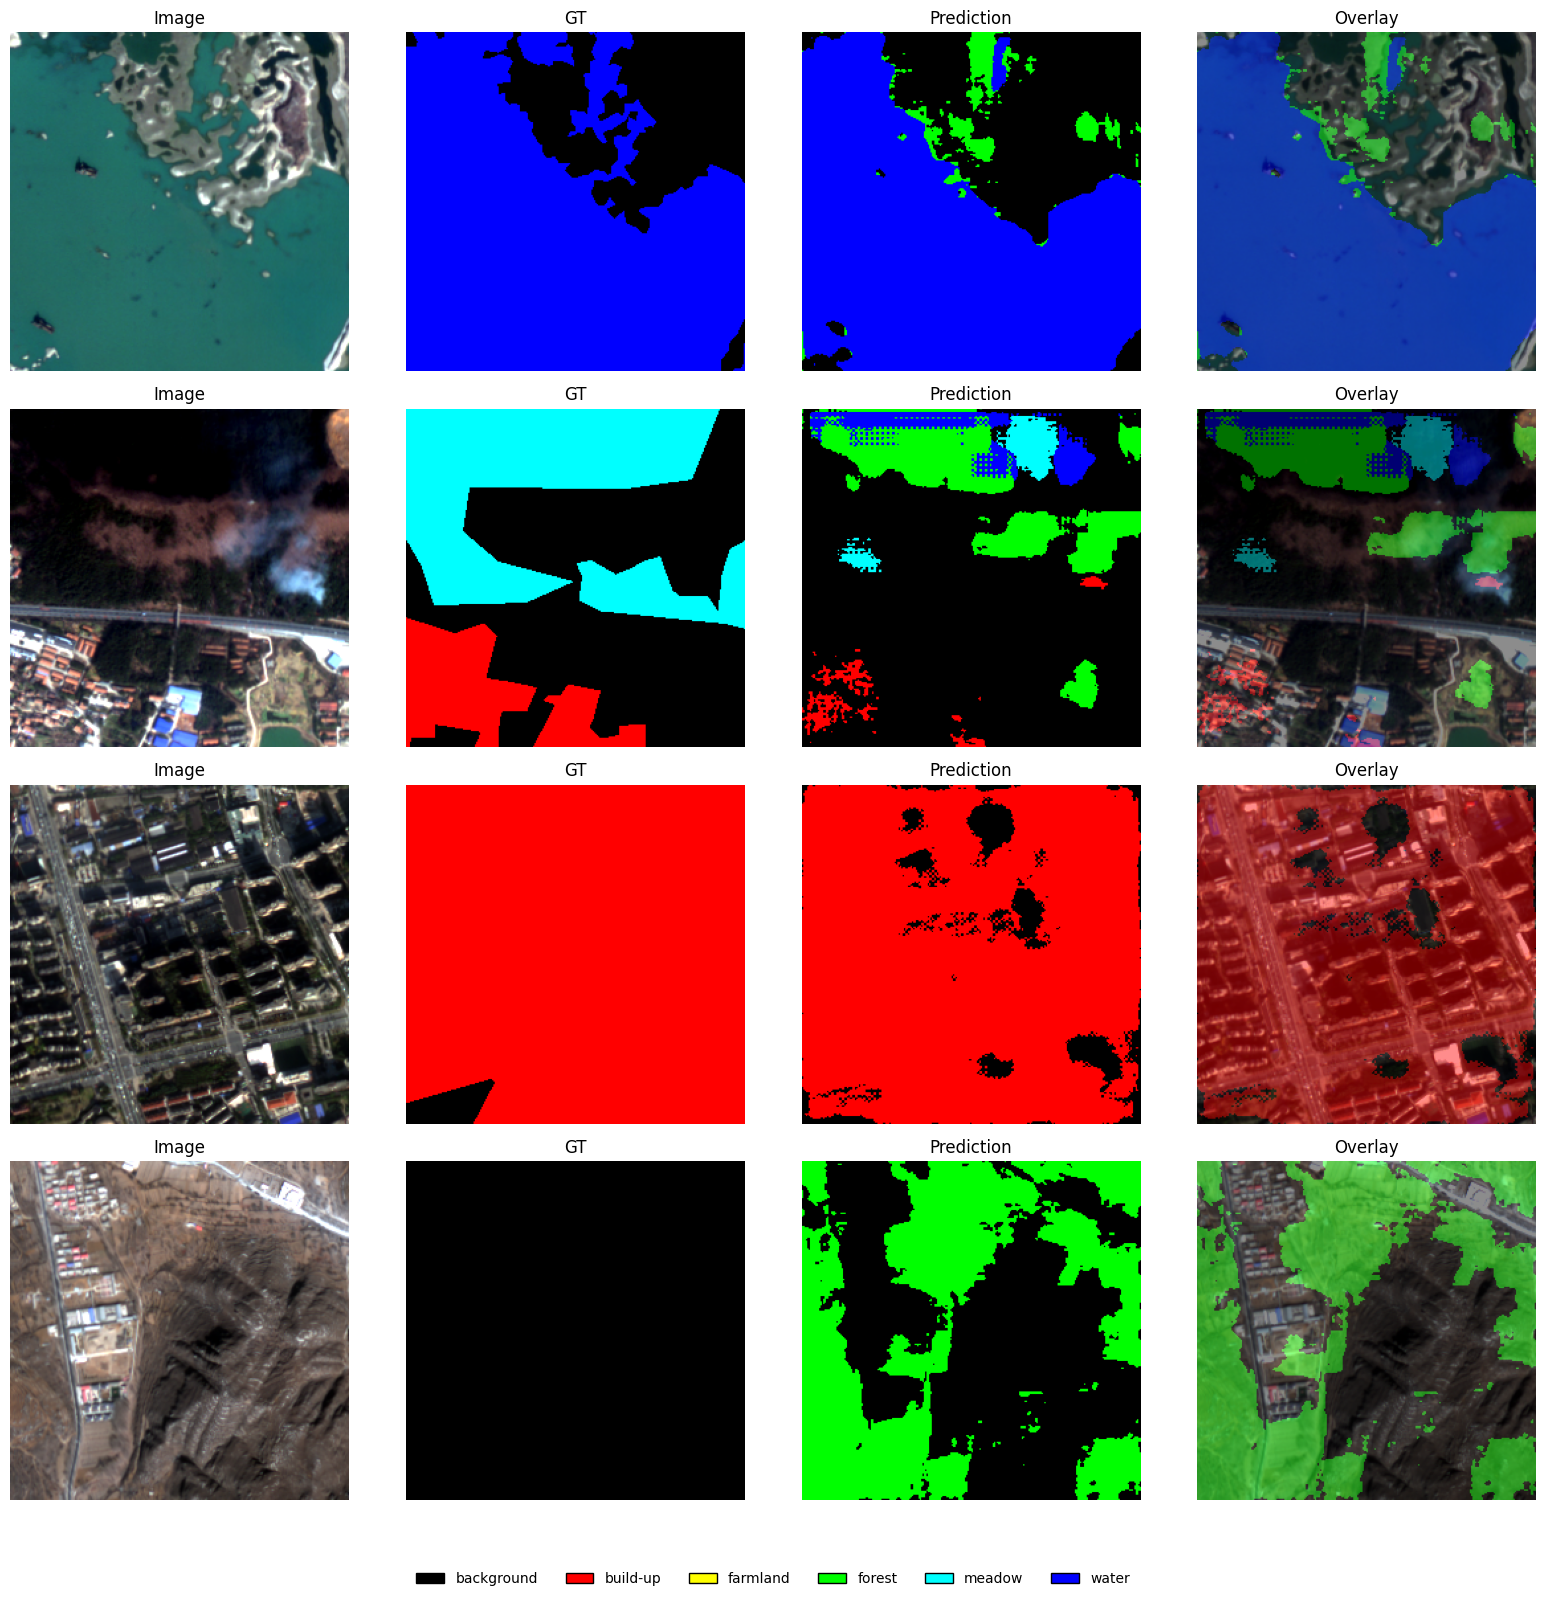

In [ ]:
from matplotlib.patches import Patch

@torch.no_grad()
def show_val_patches(model, val_loader, max_items=6, overlay_alpha=0.45):
    device = next(model.parameters()).device
    model.eval()
    xb, yb = next(iter(val_loader))
    xb = xb.to(device)
    with torch.autocast(device_type="cuda" if device.type=="cuda" else "cpu",
                         enabled=True, dtype=torch.float16):
        logits = model(xb)
    pred = logits.argmax(1).cpu().numpy()

    
    imgs = xb.cpu().permute(0,2,3,1).numpy()
    imgs = (imgs * NORM_STD + NORM_MEAN) * 255.0
    imgs = np.clip(imgs, 0, 255).astype(np.uint8)
    gts  = yb.numpy()

    n = min(len(imgs), max_items)
    fig, axs = plt.subplots(n, 4, figsize=(16, 4*n))
    if n == 1: axs = axs[None,:]
    for i in range(n):
        im  = imgs[i]; gt = colorize_idx(gts[i]); pr = colorize_idx(pred[i])
        ovl = (im.astype(np.float32)*0.55 + pr.astype(np.float32)*0.45).astype(np.uint8)
        axs[i,0].imshow(im);  axs[i,0].set_title("Image");   axs[i,0].axis('off')
        axs[i,1].imshow(gt);  axs[i,1].set_title("GT");      axs[i,1].axis('off')
        axs[i,2].imshow(pr);  axs[i,2].set_title("Prediction"); axs[i,2].axis('off')
        axs[i,3].imshow(ovl); axs[i,3].set_title("Overlay"); axs[i,3].axis('off')
    handles = [Patch(facecolor=np.array(c)/255.0, edgecolor='k', label=n)
               for c,n in zip(CLASS_COLORS, CLASS_NAMES)]
    fig.legend(handles=handles, loc="lower center", ncol=len(CLASS_NAMES), frameon=False)
    plt.tight_layout(rect=[0,0.05,1,1]); plt.show()

show_val_patches(model, val_loader, max_items=6)


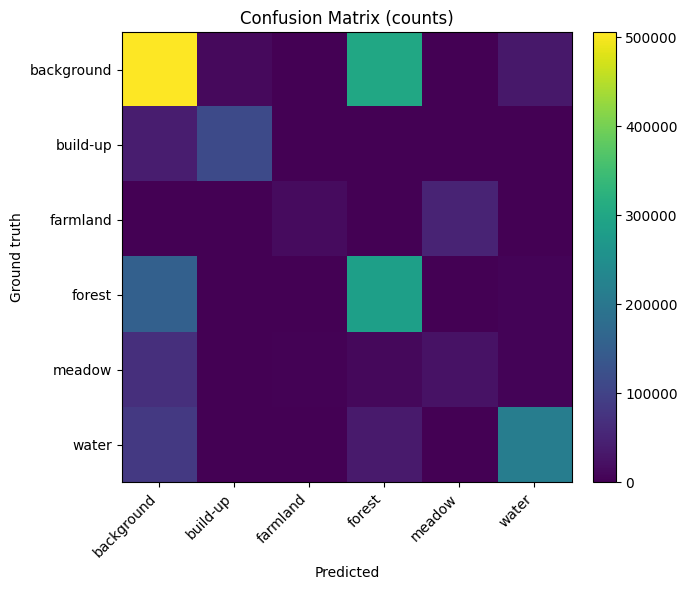

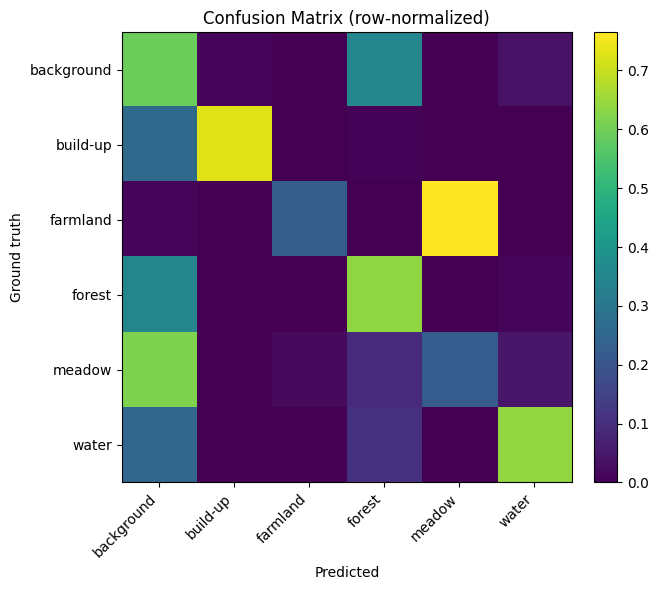

,class,support_px,PA,IoU,PA_%,IoU_%
0,background,851355,0.5940,0.4207,59.40,42.07
1,build-up,155304,0.7281,0.6722,72.81,67.22
2,farmland,65028,0.2247,0.2159,22.47,21.59
3,forest,445814,0.6387,0.3582,63.87,35.82
4,meadow,112099,0.2215,0.1528,22.15,15.28
5,water,336480,0.6396,0.5682,63.96,56.82


,metric,value,value_%
0,mIoU,0.3980,39.80
1,mPA,0.5078,50.78
2,OA,0.5891,58.91


Saved:
/content/hybrid_unet_metrics_per_class.csv
/content/hybrid_unet_metrics_summary.csv


In [ ]:
import pandas as pd

def plot_confusion_matrix(cm_np: np.ndarray, class_names, normalize=None, annotate=False):
    if normalize == 'true':
        sums = cm_np.sum(axis=1, keepdims=True)
        disp = cm_np / np.clip(sums, 1, None)
        title = "Confusion Matrix (row-normalized)"
    else:
        disp, title = cm_np, "Confusion Matrix (counts)"
    plt.figure(figsize=(7,6))
    im = plt.imshow(disp, cmap='viridis')
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.xticks(range(len(class_names)), class_names, rotation=45, ha='right')
    plt.yticks(range(len(class_names)), class_names)
    plt.xlabel("Predicted"); plt.ylabel("Ground truth"); plt.title(title)
    if annotate:
        txt = disp if normalize=='true' else cm_np
        for i in range(disp.shape[0]):
            for j in range(disp.shape[1]):
                s = f"{txt[i,j]:.2f}" if normalize=='true' else f"{int(txt[i,j])}"
                plt.text(j, i, s, ha='center', va='center', color='w', fontsize=8)
    plt.tight_layout(); plt.show()


cm_np = cm.cpu().numpy()
plot_confusion_matrix(cm_np, CLASS_NAMES, normalize=None, annotate=False)
plot_confusion_matrix(cm_np, CLASS_NAMES, normalize='true', annotate=False)


iou_list, miou, pa_list, mpa, oa = metrics_from_cm(cm)
support = cm.sum(dim=1).to(torch.int64).numpy()

df_per_class = pd.DataFrame({
    "class": CLASS_NAMES,
    "support_px": support,
    "PA": np.array(pa_list, dtype=float),
    "IoU": np.array(iou_list, dtype=float),
})
df_per_class["PA_%"]  = (df_per_class["PA"]  * 100).round(2)
df_per_class["IoU_%"] = (df_per_class["IoU"] * 100).round(2)

df_summary = pd.DataFrame({
    "metric": ["mIoU", "mPA", "OA"],
    "value":  [miou,   mpa,   oa]
})
df_summary["value_%"] = (df_summary["value"] * 100).round(2)

from IPython.display import display
display(df_per_class[["class","support_px","PA","IoU","PA_%","IoU_%"]].round(4))
display(df_summary[["metric","value","value_%"]].round(4))

# Save CSVs
out_dir = "/content"
df_per_class.to_csv(f"{out_dir}/hybrid_unet_metrics_per_class.csv", index=False)
df_summary.to_csv(f"{out_dir}/hybrid_unet_metrics_summary.csv", index=False)
print("Saved:",
      f"{out_dir}/hybrid_unet_metrics_per_class.csv",
      f"{out_dir}/hybrid_unet_metrics_summary.csv", sep="\n")


Found 30 val files


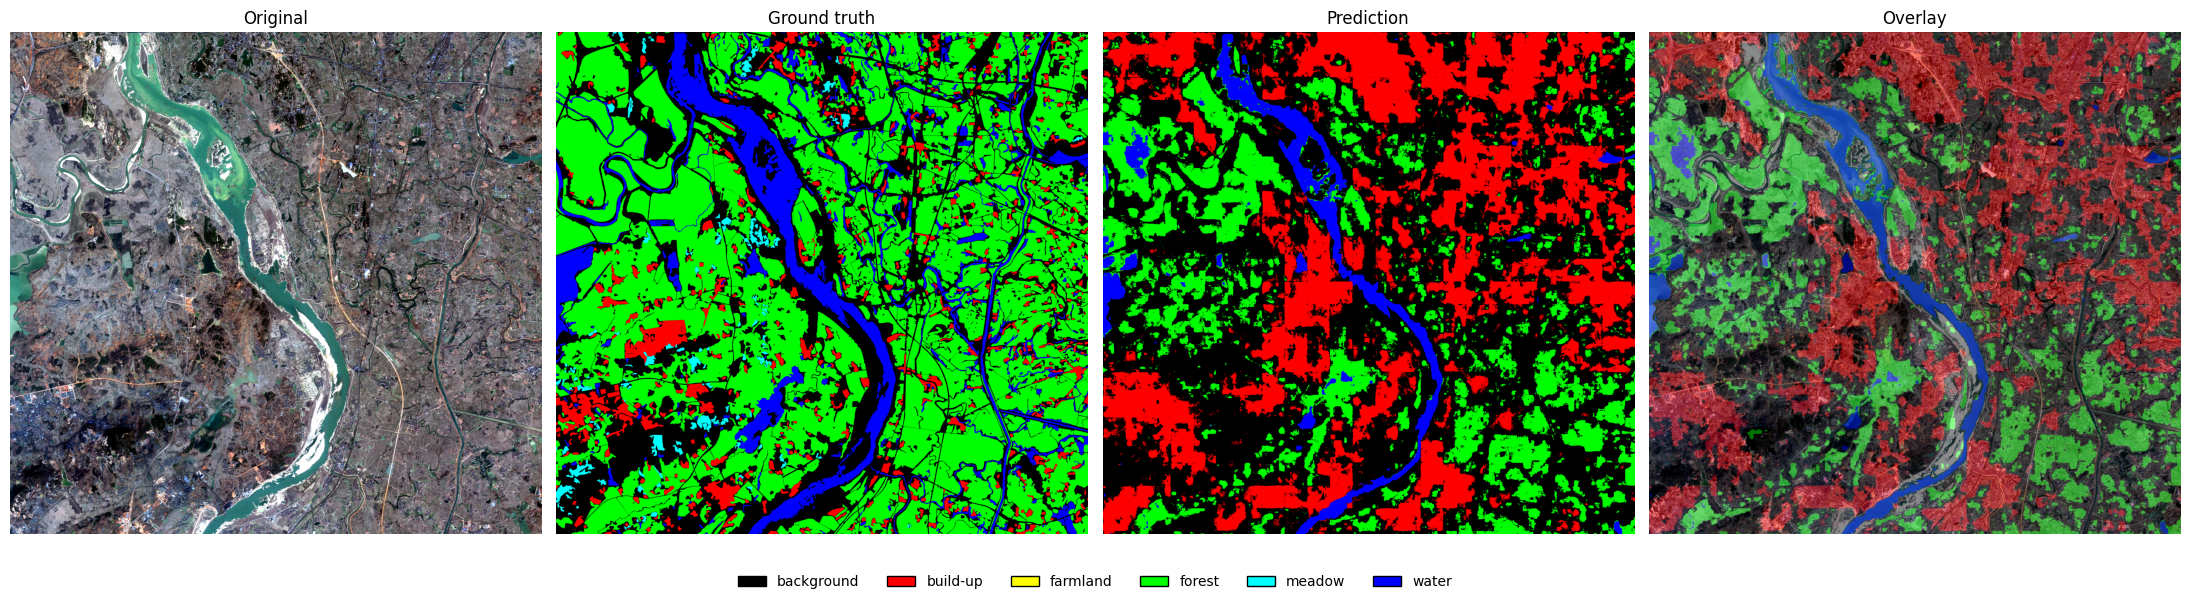

In [ ]:
@torch.no_grad()
def sliding_window_predict(model, image_path,
                           patch_size=256, stride=128,
                           device="cuda", accumulate_on="cpu",
                           downscale_long_side=3000, amp=True,
                           divisor=32):
    device = device if (device=="cuda" and torch.cuda.is_available()) else "cpu"
    acc_dev = "cpu" if accumulate_on=="cpu" else device

    im = Image.open(image_path).convert("RGB")
    W0, H0 = im.size
    scale = 1.0
    if max(W0, H0) > downscale_long_side:
        scale = downscale_long_side / float(max(W0, H0))
        im = im.resize((int(W0*scale), int(H0*scale)), Image.BILINEAR)
    W, H = im.size

    def norm_np(a):
        return (a/255.0 - NORM_MEAN) / NORM_STD

    score = torch.zeros((NUM_CLASSES, H, W), dtype=torch.float32, device=acc_dev)
    count = torch.zeros((1,          H, W), dtype=torch.float32, device=acc_dev)

    model.eval().to(device)
    for y in range(0, H, stride):
        for x in range(0, W, stride):
            patch = im.crop((x, y, min(x+patch_size, W), min(y+patch_size, H)))
            arr   = norm_np(np.array(patch, np.uint8).astype(np.float32))
            ph, pw = arr.shape[:2]

            t = torch.from_numpy(arr).permute(2,0,1).unsqueeze(0).to(device)

            
            pad_h = (divisor - (ph % divisor)) % divisor
            pad_w = (divisor - (pw % divisor)) % divisor
            if pad_h or pad_w:
                t = F.pad(t, (0, pad_w, 0, pad_h), mode="replicate")

            with torch.autocast(device_type="cuda" if device=="cuda" else "cpu",
                                 enabled=amp, dtype=torch.float16):
                logits = model(t)  

            
            logits = logits[..., :ph, :pw].squeeze(0).to(dtype=torch.float32)  

            if acc_dev == "cpu":
                score[:, y:y+ph, x:x+pw] += logits.cpu()
                count[:, y:y+ph, x:x+pw] += 1.0
            else:
                score[:, y:y+ph, x:x+pw] += logits
                count[:, y:y+ph, x:x+pw] += 1.0

    score = score / torch.clamp(count, min=1.0)
    pred  = torch.argmax(score, dim=0).cpu().numpy().astype(np.int64)

    if scale != 1.0:
        pred = np.array(Image.fromarray(pred.astype(np.uint8)).resize((W0, H0), Image.NEAREST),
                        dtype=np.int64)
    return pred


def find_mask_path(img_path: Path, mask_dir: Path, suffix="_label"):
    stem = img_path.stem
    for ext in list(MASK_EXTS) + [img_path.suffix.lower()]:
        p = Path(mask_dir) / f"{stem}{suffix}{ext}"
        if p.exists(): return p
    for p in Path(mask_dir).glob(f"{stem}*label*"):
        if p.suffix.lower() in MASK_EXTS: return p
    raise FileNotFoundError(f"No mask for {img_path.name}")

def show_full_image_triptych(img_path: Path, mask_dir: Path, model, patch_size=256, stride=128,
                             downscale_long_side=3000):
    img_path = Path(img_path); mask_dir = Path(mask_dir)
    mask_path = find_mask_path(img_path, mask_dir, "_label")
    img_rgb = np.array(Image.open(img_path).convert("RGB"))
    gt_idx  = mask_to_class_any(Image.open(mask_path))
    pred_idx = sliding_window_predict(model, img_path, patch_size, stride,
                                      device="cuda", accumulate_on="cpu",
                                      downscale_long_side=downscale_long_side, amp=True)

    gt_rgb   = colorize_idx(gt_idx)
    pred_rgb = colorize_idx(pred_idx)
    overlay  = (img_rgb.astype(np.float32)*0.55 + pred_rgb.astype(np.float32)*0.45).astype(np.uint8)

    fig, axs = plt.subplots(1,4, figsize=(22,6))
    axs[0].imshow(img_rgb);  axs[0].set_title("Original"); axs[0].axis('off')
    axs[1].imshow(gt_rgb);   axs[1].set_title("Ground truth"); axs[1].axis('off')
    axs[2].imshow(pred_rgb); axs[2].set_title("Prediction");   axs[2].axis('off')
    axs[3].imshow(overlay);  axs[3].set_title("Overlay");      axs[3].axis('off')
    handles = [Patch(facecolor=np.array(c)/255.0, edgecolor='k', label=n)
               for c,n in zip(CLASS_COLORS, CLASS_NAMES)]
    fig.legend(handles=handles, loc="lower center", ncol=len(CLASS_NAMES), frameon=False)
    plt.tight_layout(rect=[0,0.05,1,1]); plt.show()


val_imgs = sorted([p for p in Path(VAL_IMG_DIR).iterdir() if p.suffix.lower() in IMG_EXTS])
print(f"Found {len(val_imgs)} val files")
show_full_image_triptych(val_imgs[0], VAL_MASK_DIR, model, patch_size=256, stride=128, downscale_long_side=3000)
